<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task

In [163]:
!pip install pygad

In [164]:
import numpy as np
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import pygad

In [165]:
data = load_breast_cancer()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [166]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [167]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df.drop(columns="target"))

df_scaled = pd.DataFrame(
    X_scaled,
    columns=data.feature_names
)

df_scaled["target"] = y

df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0


In [168]:
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X, y)

selected_features = data.feature_names[selector.get_support()]

print(selected_features)

['mean concave points' 'worst radius' 'worst perimeter'
 'worst concave points']


To construct pairwise scatter plots, the four most informative features were selected using the SelectKBest method with the f_classif criterion. This allows us to visualize the features that best separate the classes and obtain more informative graphs than when randomly selecting features.

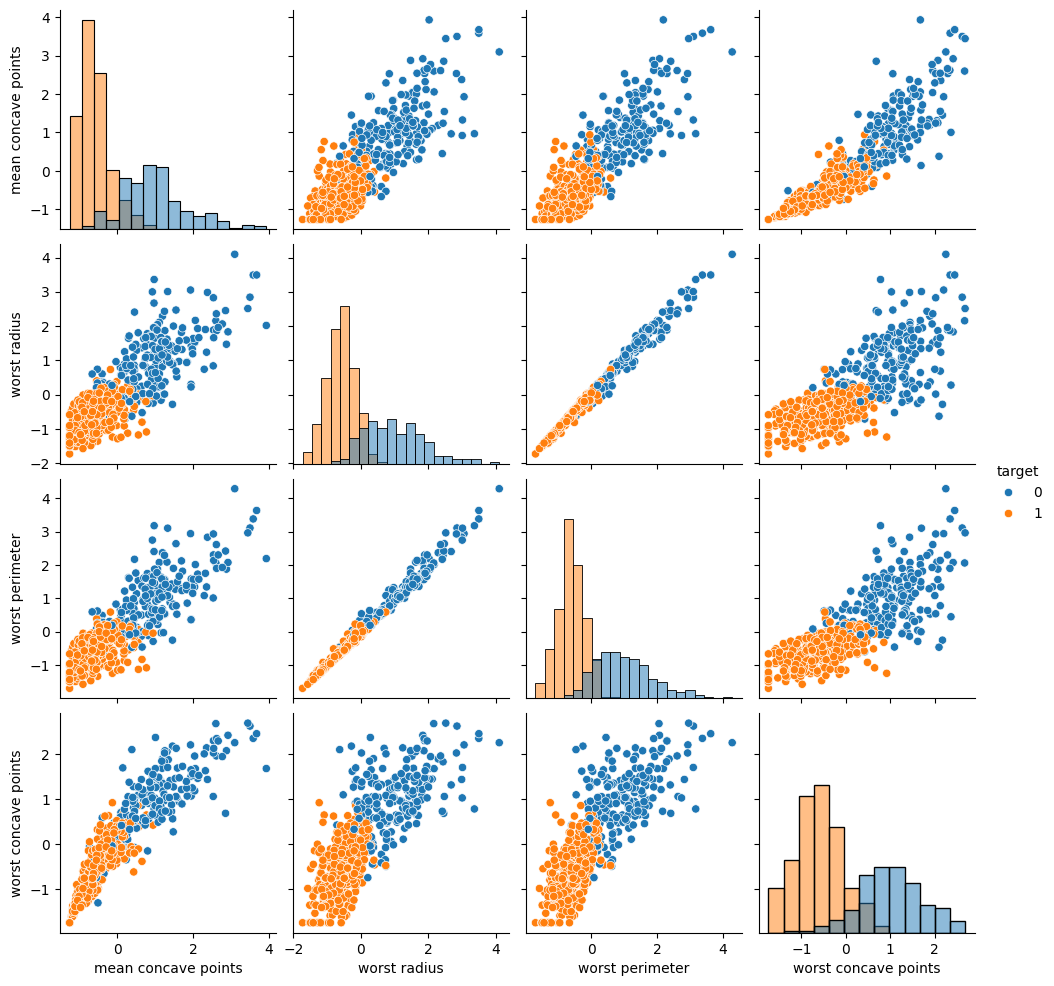

In [169]:
features = list(selected_features)

sns.pairplot(
    df_scaled[features + ["target"]],
    hue="target",
    diag_kind="hist"
)

plt.show()

In [170]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

spectral = SpectralClustering(
    n_clusters=2,
    random_state=42,
    affinity="nearest_neighbors"
)

spectral_labels = spectral.fit_predict(X_scaled)

gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

In [171]:
results = {
    "K-Means": kmeans_labels,
    "Spectral Clustering": spectral_labels,
    "Gaussian Mixture": gmm_labels
}

for name, labels in results.items():
    print(f"\n{name}")
    print("-" * 50)

    display(
        pd.crosstab(
            y,
            labels,
            rownames=["True Class"],
            colnames=["Cluster"]
        )
    )


K-Means
--------------------------------------------------


Cluster,0,1
True Class,,
0,175,37
1,13,344



Spectral Clustering
--------------------------------------------------


Cluster,0,1
True Class,,
0,182,30
1,6,351



Gaussian Mixture
--------------------------------------------------


Cluster,0,1
True Class,,
0,196,16
1,18,339


All three algorithms successfully separated the data into two clusters that corresponded well to real tumor classes, indicating that the features in the Breast Cancer dataset have high resolution.

The best clustering quality was demonstrated by Spectral Clustering.

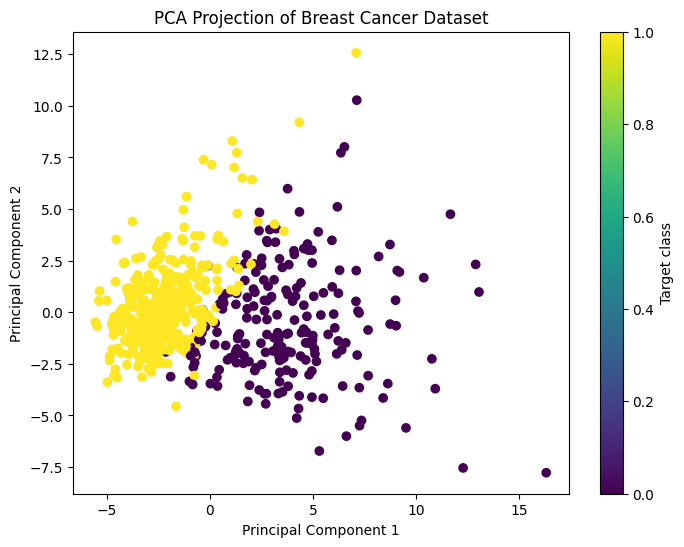

In [172]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title("PCA Projection of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target class")
plt.show()

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

unique_classes, counts = np.unique(y_train, return_counts=True)
priors_from_y = counts / counts.sum()

prior_class_df = pd.DataFrame({
    "Class": unique_classes,
    "Samples": counts,
    "Prior Probability": priors_from_y
})

display(prior_class_df)

,Class,Samples,Prior Probability
0,0,170,0.373626
1,1,285,0.626374


In [174]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

cm = confusion_matrix(y_test, predictions)
f1 = f1_score(y_test, predictions)
acc = accuracy_score(y_test, predictions)

print("Confusion Matrix:")
print(cm)

print(f"\nAccuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")

Confusion Matrix:
[[40  2]
 [ 4 68]]

Accuracy: 0.9474
F1-score: 0.9577


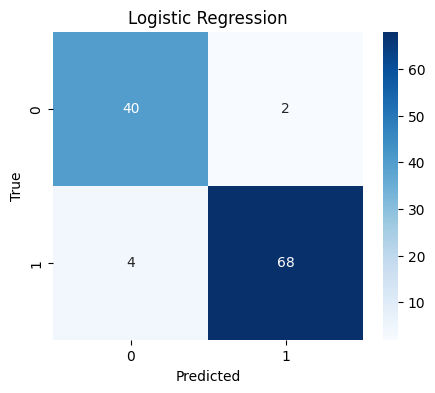

In [175]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression")
plt.show()

Batch Gradient Descent

In [176]:
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=1000):

    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    theta = np.random.randn(X_b.shape[1], 1)

    y = y.reshape(-1, 1)

    losses = []

    for epoch in range(epochs):

        z = X_b @ theta

        predictions = 1 / (1 + np.exp(-z))

        gradients = (X_b.T @ (predictions - y)) / len(y)

        theta -= learning_rate * gradients
        loss = -np.mean(
            y*np.log(predictions + 1e-15)
            + (1-y)*np.log(1-predictions + 1e-15)
        )

        losses.append(loss)

    return theta, losses

In [177]:
theta, losses = batch_gradient_descent(
    X_train,
    y_train,
    learning_rate=0.1,
    epochs=3000
)

Stochastic Gradient Descent (SGD)

In [178]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=1000):

    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    y = y.reshape(-1, 1)

    theta = np.random.randn(X_b.shape[1], 1)

    losses = []

    m = X_b.shape[0]

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X_b[indices]
        y_shuffled = y[indices]


        for i in range(m):

            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            z = xi @ theta
            prediction = 1 / (1 + np.exp(-z))

            gradient = xi.T @ (prediction - yi)

            theta -= learning_rate * gradient

        predictions = 1 / (1 + np.exp(-(X_b @ theta)))

        loss = -np.mean(
            y * np.log(predictions + 1e-15) +
            (1 - y) * np.log(1 - predictions + 1e-15)
        )

        losses.append(loss)

    return theta, losses

In [179]:
theta_sgd, losses_sgd = stochastic_gradient_descent(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=100
)

Mini-batch Gradient Descent

In [180]:
def mini_batch_gradient_descent(X, y, learning_rate=0.01, epochs=1000, batch_size=32):

    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    theta = np.random.randn(X_b.shape[1], 1)

    y = y.reshape(-1, 1)

    losses = []

    m = X_b.shape[0]

    for epoch in range(epochs):

      indices = np.random.permutation(m)
      X_shuffled = X_b[indices]
      y_shuffled = y[indices]

      for i in range(0, m, batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        z = X_batch @ theta
        predictions = 1 / (1 + np.exp(-z))
        gradient = (X_batch.T @ (predictions - y_batch)) / len(X_batch)
        theta -= learning_rate * gradient

        # Loss після завершення епохи
      predictions = 1 / (1 + np.exp(-(X_b @ theta)))

      loss = -np.mean(
          y * np.log(predictions + 1e-15) +
          (1 - y) * np.log(1 - predictions + 1e-15)
      )

      losses.append(loss)

    return theta, losses

In [181]:
theta_mini, losses_mini = mini_batch_gradient_descent(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=100,
    batch_size=32
)

Adam

In [200]:
def adam_gradient_descent(X, y, learning_rate=0.001, epochs=100, batch_size=32, beta1=0.9, beta2=0.999, epsilon=1e-8):

    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    y = y.reshape(-1, 1)
    theta = np.random.randn(X_b.shape[1], 1)
    m_theta = np.zeros_like(theta)
    v_theta = np.zeros_like(theta)

    losses = []

    n_samples = X_b.shape[0]
    t = 0

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)

        X_shuffled = X_b[indices]
        y_shuffled = y[indices]

        for i in range(0, n_samples, batch_size):

            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            z = X_batch @ theta
            predictions = 1 / (1 + np.exp(-z))

            gradient = (X_batch.T @ (predictions - y_batch)) / len(X_batch)
            t += 1

            m_theta = beta1 * m_theta + (1 - beta1) * gradient

            v_theta = beta2 * v_theta + (1 - beta2) * (gradient ** 2)
            m_hat = m_theta / (1 - beta1 ** t)
            v_hat = v_theta / (1 - beta2 ** t)

            theta -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        # Loss
        predictions = 1 / (1 + np.exp(-(X_b @ theta)))

        loss = -np.mean(
            y * np.log(predictions + 1e-15) +
            (1 - y) * np.log(1 - predictions + 1e-15)
        )

        losses.append(loss)

    return theta, losses

In [201]:
theta_adam, losses_adam = adam_gradient_descent(
    X_train,
    y_train,
    learning_rate=0.1,
    epochs=300,
    batch_size=32
)

In [202]:
def predict(X, theta):

    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    probabilities = 1 / (1 + np.exp(-(X_b @ theta)))
    predictions = (probabilities >= 0.5).astype(int)
    return predictions.ravel()

In [203]:
batch_predictions = predict(X_test, theta)
sgd_predictions = predict(X_test, theta_sgd)
mini_predictions = predict(X_test, theta_mini)
adam_predictions = predict(X_test, theta_adam)

# batch
cm_batch = confusion_matrix(y_test, batch_predictions)
f1_batch = f1_score(y_test, batch_predictions)
acc_batch = accuracy_score(y_test, batch_predictions)

# sgd
cm_sgd = confusion_matrix(y_test, sgd_predictions)
f1_sgd = f1_score(y_test, sgd_predictions)
acc_sgd = accuracy_score(y_test, sgd_predictions)

# mini
cm_mini = confusion_matrix(y_test, mini_predictions)
f1_mini = f1_score(y_test, mini_predictions)
acc_mini = accuracy_score(y_test, mini_predictions)

# adam
cm_adam = confusion_matrix(y_test, adam_predictions)
f1_adam = f1_score(y_test, adam_predictions)
acc_adam = accuracy_score(y_test, adam_predictions)

In [204]:
results = pd.DataFrame({

    "Method":[
        "Batch GD",
        "SGD",
        "Mini-Batch GD",
        "Adam"
    ],

    "Accuracy":[
        acc_batch,
        acc_sgd,
        acc_mini,
        acc_adam
    ],

    "F1-score":[
        f1_batch,
        f1_sgd,
        f1_mini,
        f1_adam
    ]
})

display(results)

,Method,Accuracy,F1-score
0,Batch GD,0.947368,0.957746
1,SGD,0.947368,0.957746
2,Mini-Batch GD,0.938596,0.951724
3,Adam,0.947368,0.957746


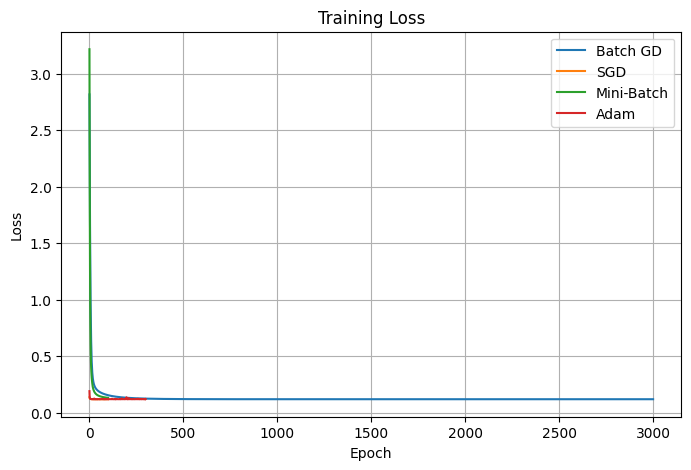

In [205]:
plt.figure(figsize=(8,5))

plt.plot(losses, label="Batch GD")
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_mini, label="Mini-Batch")
plt.plot(losses_adam, label="Adam")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid(True)

plt.show()

As is known, Batch Gradient Descent uses the entire dataset, so training was slow, but this method provided stable convergence.

SGD performed updates after each example, which accelerated training, but made the process less stable.

Mini-Batch Gradient Descent combined the advantages of the two previous methods, providing fast and stable convergence.

Adam showed the best convergence speed due to adaptive choice of the training step.

In [206]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [207]:
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [208]:
def fitness_function(ga_instance, solution, solution_idx):

    theta = solution.reshape(-1, 1)

    probabilities = sigmoid(X_train_b @ theta)

    predictions = (probabilities >= 0.5).astype(int)

    accuracy = np.mean(predictions.ravel() == y_train)

    return accuracy

In [209]:
ga = pygad.GA(
    num_generations=100,
    sol_per_pop=20,
    num_parents_mating=10,

    fitness_func=fitness_function,

    num_genes=X_train_b.shape[1],

    init_range_low=-1,
    init_range_high=1,

    mutation_percent_genes=20,

    random_mutation_min_val=-0.5,
    random_mutation_max_val=0.5,

    parent_selection_type="sss",

    crossover_type="single_point",

    mutation_type="random",

    random_seed=42
)

ga.run()

/usr/local/lib/python3.12/dist-packages/pygad/utils/validation.py:986: UserWarning: The percentage of genes to mutate (mutation_percent_genes=20) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


In [210]:
solution, fitness, _ = ga.best_solution()
theta_ga = solution.reshape(-1, 1)
print("Best Fitness:", fitness)

Best Fitness: 0.9626373626373627


In [211]:
probabilities = sigmoid(X_test_b @ theta_ga)
ga_predictions = (probabilities >= 0.5).astype(int).ravel()

In [212]:
cm_ga = confusion_matrix(y_test, ga_predictions)
f1_ga = f1_score(y_test, ga_predictions)
acc_ga = accuracy_score(y_test, ga_predictions)

print(cm_ga)
print("Accuracy:", acc_ga)
print("F1:", f1_ga)

[[40  2]
 [ 4 68]]
Accuracy: 0.9473684210526315
F1: 0.9577464788732394


In [213]:
ga_losses = [-fitness for fitness in ga.best_solutions_fitness]

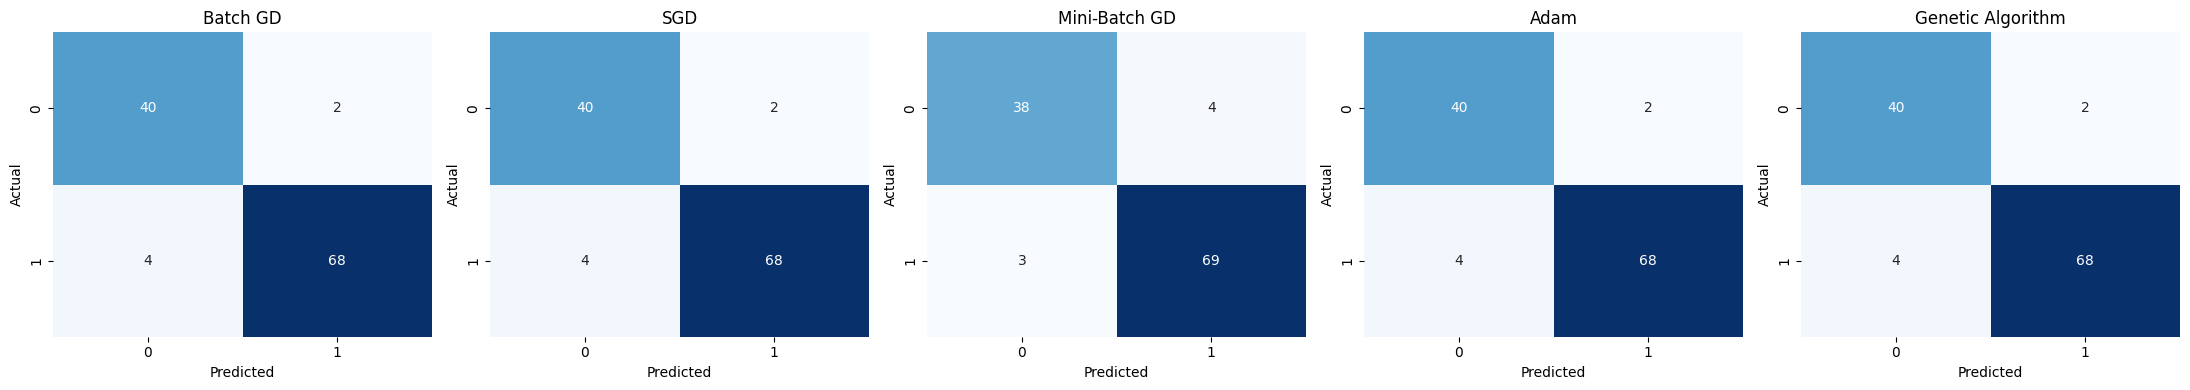

In [214]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

cms = [
    confusion_matrix(y_test, batch_predictions),
    confusion_matrix(y_test, sgd_predictions),
    confusion_matrix(y_test, mini_predictions),
    confusion_matrix(y_test, adam_predictions),
    confusion_matrix(y_test, ga_predictions)
]

titles = [
    "Batch GD",
    "SGD",
    "Mini-Batch GD",
    "Adam",
    "Genetic Algorithm"
]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Batch GD, SGD, Adam and Genetic Algorithm have 4 False Negatives and 2 False Positives.
Mini-Batch GD has 3 False Negatives (better) and 4 False Positives (worse).

Mini-Batch makes mistakes more often overall but makes fewer of the most dangerous mistakes.

In [217]:
results_fn = pd.DataFrame({
    "Method": [
        "Batch GD",
        "SGD",
        "Mini-Batch GD",
        "Adam",
        "Genetic Algorithm"
    ],
    "Accuracy": [
        acc_batch,
        acc_sgd,
        acc_mini,
        acc_adam,
        acc_ga
    ],
    "F1-score": [
        f1_batch,
        f1_sgd,
        f1_mini,
        f1_adam,
        f1_ga
    ],
    # "Final Metric": [
    #     losses[-1],
    #     losses_sgd[-1],
    #     losses_mini[-1],
    #     losses_adam[-1],
    #     ga_losses[-1]
    # ],
    "Iterations": [
        len(losses),
        len(losses_sgd),
        len(losses_mini),
        len(losses_adam),
        len(ga_losses)
    ]
})

results_fn

,Method,Accuracy,F1-score,Iterations
0,Batch GD,0.947368,0.957746,3000
1,SGD,0.947368,0.957746,100
2,Mini-Batch GD,0.938596,0.951724,100
3,Adam,0.947368,0.957746,300
4,Genetic Algorithm,0.947368,0.957746,101


# Summary

In medical diagnosis, False Negatives (FN) are considered more critical than False Positives (FP) because a false negative means that a malignant tumor is incorrectly classified as benign, potentially delaying treatment. A false positive usually leads to additional diagnostic examinations, which are less harmful than missing a serious disease.

According to Accuracy and F1-score, Batch Gradient Descent, SGD, Adam, and the Genetic Algorithm demonstrated the best overall classification performance, while Mini-Batch Gradient Descent achieved slightly lower overall accuracy.

However, the confusion matrices show that Mini-Batch Gradient Descent produced fewer False Negatives (3 instead of 4), which is particularly important in medical diagnosis because missing a malignant tumor is more critical than generating an additional false alarm. Therefore, although Mini-Batch Gradient Descent has slightly lower overall metrics, it provides the best performance in terms of reducing the most critical type of classification error.